2025-12-15 创建
1. 解决风-浪场的预报功能
2. 使用U-Net CNN神经网络
3. 加入了Boosting机制

In [1]:
import os
import subprocess
import sys

# === 关键：这段代码必须放在 import torch 之前运行 ===
def get_freest_gpu():
    try:
        # 查询显存剩余量
        result = subprocess.check_output(
            "nvidia-smi --query-gpu=memory.free --format=csv,nounits,noheader",
            shell=True, text=True)
        free_mems = [int(x) for x in result.strip().split('\n')]
        # 找到剩余内存最大的 GPU 索引
        best_gpu = free_mems.index(max(free_mems))
        return best_gpu
    except Exception as e:
        print(f"自动选择 GPU 失败: {e}，将使用默认 GPU 0")
        return 0

# 获取最空闲的 GPU
best_gpu = get_freest_gpu()

# 设置环境变量（必须在 import torch 之前！）
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = str(best_gpu)
print(f"已设置 CUDA_VISIBLE_DEVICES = {best_gpu} (物理 GPU)")

# === 之后再导入 torch ===
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
# 自建函数库
from main_python_MyFunctions import c_PickleHandler

# 检查当前 PyTorch 看到的设备
# 如果设置成功，torch.cuda.current_device() 应该是 0，但它对应的是物理 GPU 1
if torch.cuda.is_available():
    print(f"PyTorch 当前使用设备: cuda:0")
    print(f"该设备属性: {torch.cuda.get_device_name(0)}")


已设置 CUDA_VISIBLE_DEVICES = 0 (物理 GPU)


d:\Softwares\Anaconda3\envs\cnn-model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 当前使用设备: cuda:0
该设备属性: NVIDIA GeForce GTX 1660 Ti


# 数据处理环节

In [2]:
import f_FilesMethods
# 加载台风id数据
id = f_FilesMethods.read_matlab_mat('../datas/Id_regional.mat', 'Id')
id = id[0]
print("id shape =", id.shape)

id shape = (6124,)


需要移除id等于201623、201723、202203的数据

In [3]:
sample_indices_to_remove = np.where((id == 201623) | (id == 201723) | (id == 202203))[0]
# print(f"剔除的样本索引: {sample_indices_to_remove}")
print(f"剔除的样本数量: {len(sample_indices_to_remove)}")

剔除的样本数量: 56


## 加载数据

### 加载pkl数据
文件路径../datas/*.pkl

二维为*_2d.pkl；一维为*_piled.pkl

In [4]:
import gc  # 关键：手动垃圾回收

def f_load_pickle(file_path):
    handle = c_PickleHandler(file_path)
    data = handle.load_data()
    return data

   
# 读取文件
print('**loading files ...')

# env_type = input("Please input the environment type (wave, surge, current): ")
env_type = 'wave'  # 'wave' ,'surge', 'current'

# 读取mat文件
wind_2d = f_load_pickle('../datas/wind_regional_2d.pkl') # wind_2d.pkl或wind_era5_2d.pkl

output_map_2d = f_load_pickle('../datas/wave_regional_2d.pkl')
# 剔除output_map_2d中id等于201623、201723、202203的数据
output_map_2d = np.delete(output_map_2d, sample_indices_to_remove, axis=0)

# 立即释放大对象
del f_load_pickle
gc.collect()

# 正确提取 wind_2d 的 real 和 imag（关键修复：用 fields 访问）
wind_real = wind_2d['real'].astype(np.float32)  # (110387, 56, 54), 纯 float64
wind_imag = wind_2d['imag'].astype(np.float32)  # 同上
# 剔除wind_2d中id等于201623、201723、202203的数据
wind_real = np.delete(wind_real, sample_indices_to_remove, axis=0)
wind_imag = np.delete(wind_imag, sample_indices_to_remove, axis=0)
wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (110387, 2, 56, 54), 纯 float64
# 清理原始 dict
del wind_2d, wind_real, wind_imag
gc.collect()

# 剔除id中等于201623、201723、202203的数据
id = np.delete(id, sample_indices_to_remove, axis=0)

# 网格数据
# x = np.arange(105.3, 116.01, 0.2, dtype = float)
# y = np.arange(12, 23.01, 0.2, dtype = float)
# x = np.linspace(105.3, 116.0, 64, dtype = float)
# y = np.linspace(12.0, 23.0, 64, dtype = float)
x = np.linspace(110.5, 113.5, 64, dtype = float)
y = np.linspace(17.5, 20.5, 64, dtype = float)
X,Y = np.meshgrid(x, y)

print("Data loading fixed: wind_combined dtype =", wind_combined.dtype)  # 应为 float64
print("Data loading fixed: wind_combined shape =", wind_combined.shape)

print("data shape (wave): ",output_map_2d.shape)
print('Id shape:', id.shape)

**loading files ...
Data loading fixed: wind_combined dtype = float32
Data loading fixed: wind_combined shape = (6068, 2, 64, 64)
data shape (wave):  (6068, 64, 64)
Id shape: (6068,)


In [5]:
# 分析output_map_2d在axis=0上的最小值
if env_type == 'surge' or env_type == 'wave':
    output_2d_min = np.nanmin(output_map_2d, axis=(1,2))
    print("output_map_2d min along axis 0:", output_2d_min)
# 查询output_2d_min中小于-1000的值的索引
    extreme_indices = np.where(output_2d_min < -1000)[0]
    print("Indices with extreme low values (< -1000):", extreme_indices)

output_map_2d min along axis 0: [0. 0. 0. ... 0. 0. 0.]
Indices with extreme low values (< -1000): []


### 检查数据异常值
报告数据异常值数量

In [6]:
# 检查原始数据中的 NaN/Inf
print("Wind data stats:")
print(f"NaN in wind: {np.any(np.isnan(wind_combined))}")
print(f"Inf in wind: {np.any(np.isinf(wind_combined))}")

print("\nOutput data stats:")
print(f"NaN in output_map_2d: {np.any(np.isnan(output_map_2d))}")
print(f"Inf in output_map_2d: {np.any(np.isinf(output_map_2d))}")

# 示例：打印有 NaN 的样本索引（如果有）
nan_wind_idx = np.where(np.isnan(wind_combined).any(axis=(1,2,3)))
nan_output_idx = np.where(np.isnan(output_map_2d).any(axis=(1,2)))
print(f"Wind NaN samples: {len(nan_wind_idx[0])}")
print(f"Output NaN samples: {len(nan_output_idx[0])}")

# 如果有 NaN，查看范围
print(f"Wind min/max: {np.nanmin(wind_combined):.2f} / {np.nanmax(wind_combined):.2f}")
print(f"Output min/max: {np.nanmin(output_map_2d):.2f} / {np.nanmax(output_map_2d):.2f}")


Wind data stats:
NaN in wind: False
Inf in wind: False

Output data stats:
NaN in output_map_2d: True
Inf in output_map_2d: False
Wind NaN samples: 0
Output NaN samples: 6068
Wind min/max: -31.00 / 30.98
Output min/max: 0.00 / 24.76


### 清除数据异常值并进行归一化

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 清理 NaN/Inf：替换为 0（或均值），或删除样本
# 选项1: 替换（简单，保留所有样本）
# wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
# output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0)
output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0)
del wind_combined, output_map_2d
gc.collect()

N, C, H, W = wind_combined_clean.shape

print("Cleaned data stats:")
print(f"NaN in cleaned wind: {np.any(np.isnan(wind_combined_clean))}")
print(f"NaN in cleaned output: {np.any(np.isnan(output_map_2d_clean))}")

# 全局归一化：将所有样本和空间位置一起归一化
'''wind_reshaped = wind_combined_clean.transpose(0, 2, 3, 1).reshape(-1, C)
print(f"Wind reshaped for global scaling: {wind_reshaped.shape}") # 应该是 (*, 2)
scaler_wind = MinMaxScaler(feature_range=(-1, 1))
# 注意：transform 接收 (M, 2)，输出 (M, 2)，需要再变回 (N, 2, 64, 64)
wind_normalized_flat = scaler_wind.fit_transform(wind_reshaped)
# 还原形状: (N*H*W, C) -> (N, H, W, C) -> (N, C, H, W)
wind_normalized = wind_normalized_flat.reshape(N, H, W, C).transpose(0, 3, 1, 2)'''
# 全局归一化：风速
wind_reshaped = wind_combined_clean.reshape(N, -1)  # (N, C*H*W)
print(f"Wind reshaped for global scaling: {wind_reshaped.shape}") # 应该是 (N, 2*56*54)
scaler_wind = MinMaxScaler(feature_range=(-1, 1))
# 注意：transform 接收 (N, D)，输出 (N, D)，需要再变回 (N, C, H, W)
wind_normalized_flat = scaler_wind.fit_transform(wind_reshaped)
# 还原形状: (N, C*H*W) -> (N, C, H, W)
wind_normalized = wind_normalized_flat.reshape(N, C, H, W)


# 立即释放内存
del wind_reshaped, wind_normalized_flat
gc.collect()

# 输出变量归一化
if env_type == 'current':
    # Current 也是 2 通道
    N, C, H, W = output_map_2d_clean.shape
    out_reshaped = output_map_2d_clean.transpose(0, 2, 3, 1).reshape(-1, C)
    
    scaler_output = MinMaxScaler(feature_range=(-1, 1))
    out_normalized_flat = scaler_output.fit_transform(out_reshaped)
    output_normalized = out_normalized_flat.reshape(N, H, W, C).transpose(0, 3, 1, 2)

    del out_reshaped, out_normalized_flat
    gc.collect()    
else:
    # Surge / Wave 是 1 通道 (N, 64, 64) -> (N*64*64, 1)
    '''output_flat = output_map_2d_clean.reshape(-1, 1)'''
    output_flat = output_map_2d_clean.reshape(N, -1)
    
    if env_type == 'surge':
        scaler_output = MinMaxScaler(feature_range=(-1, 1))
    elif env_type == 'wave':
        scaler_output = MinMaxScaler(feature_range=(0, 1))
        
    out_normalized_flat = scaler_output.fit_transform(output_flat)
    output_normalized = out_normalized_flat.reshape(output_map_2d_clean.shape)

    # 立即释放内存
    del output_flat, out_normalized_flat
    gc.collect()

# 保存wind和output的scaler
import joblib
import os
save_dir = "../datas/"
os.makedirs(save_dir, exist_ok=True)
joblib.dump(scaler_wind,   os.path.join(save_dir, "scaler_wind.joblib"))
joblib.dump(scaler_output, os.path.join(save_dir, f"scaler_{env_type}.joblib"))
print("Global Scalers saved.")

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")
print(f"Output normalized min/max: {np.nanmin(output_normalized):.2f} / {np.nanmax(output_normalized):.2f}")

Cleaned data stats:
NaN in cleaned wind: False
NaN in cleaned output: False
Wind reshaped for global scaling: (6068, 8192)
Global Scalers saved.
Normalized wind NaN: False
Normalized output NaN: False
Wind normalized min/max: -1.00 / 1.00
Output normalized min/max: 0.00 / 1.00


#### 绘制归一化风场

TC id: 200020
Same Index: [ 20  19  18  17  16  15  14  13  12  11  10   9   8   7   6   5   4   3
   2   1   0  -1  -2  -3  -4  -5  -6  -7  -8  -9 -10]


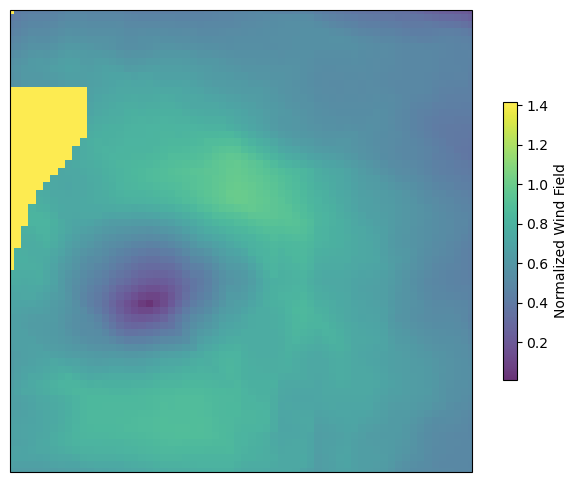

In [8]:
sample_idx = 4770# 84710 Damrey # 97480 Haiyan # 100120 Sarika # 97950 rammasun # 取第sample_idx个样本；可改成其他索引
print("TC id: %d" % id[sample_idx])
print(f"Same Index: {sample_idx - np.where(id==id[sample_idx])[0]}")

import cartopy.crs as ccrs
wind_field_np = np.sqrt(wind_normalized[sample_idx, 0, :, :]**2 + wind_normalized[sample_idx, 1, :, :]**2)

extent = [np.min(x), np.max(x), np.min(y), np.max(y)]
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ax.set_extent(extent, crs=ccrs.PlateCarree())
im = ax.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im, ax=ax, label='Normalized Wind Field', shrink=0.6)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
plt.show()

## 数据转化为训练数据

In [9]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class NumpyDataset(Dataset):
    def __init__(self, wind_data, output_data):
        # 关键：只保存引用，不复制！
        self.wind_data = wind_data      # (N, 2, 56, 54) float64
        self.output_data = output_data  # (N, 56, 54) float64
        assert len(self.wind_data) == len(self.output_data), "Length mismatch!"

    def __len__(self):
        return len(self.wind_data)

    def __getitem__(self, idx):
        # 动态转换：只转换当前样本，内存极小
        wind = torch.from_numpy(self.wind_data[idx].astype(np.float32))      # (2,56,54)
        # output = torch.from_numpy(self.output_data[idx].astype(np.float32)).unsqueeze(0)  # (1,56,54)
        out_data = self.output_data[idx].astype(np.float32)
        if out_data.ndim == 2: # (H, W) -> 增加通道维 -> (1, H, W)
            output = torch.from_numpy(out_data).unsqueeze(0)
        else: # (C, H, W) -> 保持原样
            output = torch.from_numpy(out_data)
            
        return wind, output

# === 使用 ===
dataset = NumpyDataset(wind_normalized, output_normalized)
# dataset = NumpyDataset(wind_combined_resampled, output_map_resampled)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0)

print(f"Dataset size: {len(dataset)}")

Dataset size: 6068


# 模型设置

## 损失函数

- `CombinedLoss2`: MSE + L1
- `CombinedLoss3`: MSE + Gradient + Quantile
- `HighValueDiceLoss`: Dice loss for high values
- `QuantileLoss`: Single quantile loss
- `CombinedQuantileLoss`: Lower quantile + MSE + Upper quantile


In [10]:
# 损失函数
import torch
import torch.nn as nn
import torch.nn.functional as F


# 自定义损失函数：CombinedLoss (MSE + L1)
class CombinedLoss2(nn.Module):
    def __init__(self, alpha=0.5):  # alpha: MSE 权重，1-alpha: L1 权重
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        l1_loss = self.l1(pred, target)
        return self.alpha * mse_loss + (1 - self.alpha) * l1_loss

# 组合损失
class CombinedLoss3(nn.Module):
    def __init__(self, alpha=0.5, beta=0.3, gamma=0.2):
        super().__init__()
        self.alpha = alpha  # MSE权重
        self.beta = beta    # 梯度损失权重
        self.gamma = gamma  # 分位数损失权重
        
    def forward(self, pred, target):
        # MSE损失
        mse_loss = nn.functional.mse_loss(pred, target)
        SmoothL1_loss = nn.functional.smooth_l1_loss(pred, target)
        
        # 梯度损失 - 保持空间结构
        grad_x_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
        grad_x_target = target[:, :, :, 1:] - target[:, :, :, :-1]
        grad_y_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
        grad_y_target = target[:, :, 1:, :] - target[:, :, :-1, :]
        
        grad_loss = (nn.functional.mse_loss(grad_x_pred, grad_x_target) + 
                     nn.functional.mse_loss(grad_y_pred, grad_y_target))
        
        # 分位数损失 - 关注极值
        quantiles = [0.1, 0.9]  # 低值和高值分位数
        # quantiles = [0.9]
        quantile_loss = 0
        for q in quantiles:
            errors = target - pred
            quantile_loss += torch.max(q * errors, (q-1) * errors).mean()
            # quantile_loss += torch.quantile(torch.max(q * errors, (q-1) * errors), q)
        
        return self.alpha * SmoothL1_loss + self.beta * grad_loss + self.gamma * quantile_loss

# 自定义损失函数：HighValueDiceLoss
class HighValueDiceLoss(nn.Module):
    def __init__(self, threshold_factor=0.8, smooth=1e-6, reduction='mean'):
        """
        Dice Loss for high wave regions (> threshold_factor * per-sample max_wave).
        - threshold_factor: 0.8 表示每个样本的 0.8 * max_wave
        - smooth: 平滑项，避免除零
        - reduction: 'mean' (batch 平均) 或 'sum'
        """
        super(HighValueDiceLoss, self).__init__()
        self.threshold_factor = threshold_factor
        self.smooth = smooth
        self.reduction = reduction

    def forward(self, pred, target):
        # 处理 NaN/Inf（从你的数据清理继承）
        pred = torch.nan_to_num(pred, nan=0.0, posinf=1.0, neginf=0.0)
        target = torch.nan_to_num(target, nan=0.0, posinf=1.0, neginf=0.0)
        
        batch_size, _, H, W = target.shape
        
        # Per-sample max_wave: [batch] 形状
        per_sample_max = target.view(batch_size, -1).max(dim=1)[0]  # 每个样本的最大波高
        
        # 处理 max=0 的边缘情况（全低波，避免阈值=0）
        per_sample_max = torch.clamp(per_sample_max, min=1e-6)  # 最小阈值避免除零/全背景
        
        # Per-sample threshold: [batch] -> [batch, 1, 1, 1] 广播到 [batch,1,H,W]
        threshold = self.threshold_factor * per_sample_max.unsqueeze(1).unsqueeze(2).unsqueeze(3)
        
        # 阈值化：高波区为 1
        target_binary = (target > threshold).float()  # [batch,1,H,W]
        pred_sigmoid = torch.sigmoid(pred)  # 激活预测到 [0,1]
        pred_binary = (pred_sigmoid > threshold).float()  # 逐样本阈值化
        
        # 计算交集和并集（逐像素 sum，dim=(2,3) 忽略 H,W）
        intersection = (pred_binary * target_binary).sum(dim=(2, 3))  # [batch,1]
        pred_sum = pred_binary.sum(dim=(2, 3))
        target_sum = target_binary.sum(dim=(2, 3))
        
        # Dice 分数
        dice = (2. * intersection + self.smooth) / (pred_sum + target_sum + self.smooth)
        
        # 损失：1 - dice，batch 平均
        loss = 1 - dice.squeeze(1)  # 去掉通道维 [batch]
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # 无 reduction，返回 [batch]

# 自定义分位数损失函数
class QuantileLoss(nn.Module):
    def __init__(self, q=0.9):
        super(QuantileLoss, self).__init__()
        self.q = q

    def forward(self, pred, tgt):
        r = tgt - pred
        loss = torch.max(self.q * r, (self.q - 1) * r)
        return torch.mean(loss)
    
   
# 自定义融合分位数损失
class CombinedQuantileLoss(nn.Module):
    def __init__(self, alpha=0.4, beta=0.2, gamma=0.4, upper_q=0.9, lower_q=0.1):
        super().__init__()
        self.alpha = alpha  # 下分位数损失权重
        self.beta = beta    # 其他损失权重
        self.gamma = gamma  # 上分位数损失权重
        self.upper_q = upper_q
        self.lower_q = lower_q

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """
        pred, target : (B, C, H, W)   # 必须是同一形状
        """
        # 1. 全局 MSE
        mse_loss = F.mse_loss(pred, target, reduction='mean')

        # 2. 计算当前 batch 的上/下分位阈值（按像素值统计）
        #   flatten → quantile → 恢复原始形状的 mask
        flat = target.view(target.shape[0], -1)                 # (B, N)
        upper_thr = torch.quantile(flat, self.upper_q, dim=1)   # (B,)
        lower_thr = torch.quantile(flat, self.lower_q, dim=1)   # (B,)

        # 广播为 (B, 1, H, W) 的阈值张量
        upper_thr = upper_thr.view(-1, 1, 1, 1)
        lower_thr = lower_thr.view(-1, 1, 1, 1)

        # 3. 构造 mask
        #    high_region : 真实值 > 90% 分位
        #    low_region  : 真实值 < 10% 分位
        high_region = target > upper_thr          # (B, C, H, W)
        low_region  = target < lower_thr

        # 4. 上分位数 MAE（只在 high_region 且 pred < target 时惩罚）
        upper_err = F.l1_loss(pred, target, reduction='none')   # (B, C, H, W)
        upper_mask = high_region & (pred < target)
        upper_quantile_loss = (upper_err * upper_mask.float()).sum() / (upper_mask.float().sum() + 1e-8)

        # 5. 下分位数 MAE（只在 low_region 且 pred > target 时惩罚）
        lower_err = F.l1_loss(pred, target, reduction='none')
        lower_mask = low_region & (pred > target)
        lower_quantile_loss = (lower_err * lower_mask.float()).sum() / (lower_mask.float().sum() + 1e-8)

        # 6. 复合损失
        loss = (self.alpha * upper_quantile_loss +
                self.beta  * mse_loss +
                self.gamma * lower_quantile_loss)

        return loss

# 自定义加权MAE损失
class WeightedMAELoss(nn.Module):
    def __init__(self):
        super(WeightedMAELoss, self).__init__()

    def forward(self, preds, targets):
        # 计算残差
        residuals = targets - preds  # (B, C, H, W)

        # 计算加权 MAE，权重是targets的绝对值
        weights = torch.abs(targets)  # (B, C, H, W)
        weighted_residuals = weights * torch.abs(residuals)  # (B, C, H, W)
        loss = torch.mean(weighted_residuals)/torch.mean(weights)

        return loss

## 添加模型

In [11]:
import torch
# 关键步骤：导入类定义
from f_model_defination import UNetBoosting, TreeUNetManager, XGBoostUNet

# 贝叶斯优化模型参数

In [12]:
import optuna
import torch
import torch.optim as optim
import gc # 用于垃圾回收，防止显存泄漏

# === 实例化模型 ===
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ================== 永久双卡加速神器（只加这一段，永远有效）==================
torch.cuda.set_device(0)
device = torch.device("cuda:0")
print(f"本 notebook 已绑定到物理 GPU {best_gpu}")


def objective(trial):
    # ==============================
    # 1. 定义超参数搜索空间
    # ==============================
    # num_models: 整数
    num_models = trial.suggest_int('num_models', 4, 10)

    # shrinkage: 浮点数
    shrinkage = trial.suggest_float('shrinkage', 0.4, 0.9, step=0.1)
    

    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    # lr = 1e-3 # 固定学习率

    print(f"\n--- Trial {trial.number} Start: num_models={num_models}, shrinkage={shrinkage:.2f} ---")

    # ==============================
    # 2. 实例化模型
    # ==============================
    # 使用 trial 建议的参数实例化模型
    model = XGBoostUNet(
        num_models=num_models,
        learning_rate=lr, 
        shrinkage=shrinkage,       # <--- 动态参数
        subsample=0.8,             # 也可以：trial.suggest_float('sub', 0.5, 1.0)
        reg_lambda=1e-4,
        features=[16, 32, 64, 128],
        env_type='wave',           # 确保这里和你当前任务一致
        device=device
    ).to(device)

    # ==============================
    # 3. 准备 Loss 和 Scheduler
    # ==============================
    # 注意：每次 trial 都要重新实例化
    criterion = CombinedLoss3(alpha=0.2, beta=0.4, gamma=0.4).to(device)
    
    def scheduler_func(opt):
        return optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

    # ==============================
    # 4. 训练模型
    # ==============================
    try:
        # 为了加快搜索速度，这里可以适当减少 num_epochs 和 patience
        # 比如正式训练用 150，搜索时用 30-50 即可看出优劣
        _, _, ensemble_val_loss = model.train_ensemble(
            train_loader=train_loader,
            val_loader=val_loader,
            criterion_base=criterion, 
            scheduler_func=scheduler_func,
            num_epochs=100,    # <--- 调参时设小一点，节约时间
            patience=5        # <--- 早停耐心也设小一点
        )
        
        # ==============================
        # 5. 计算优化指标
        # ==============================
        # val_losses 是一个嵌套列表，val_losses[i] 是第 i 个 booster 在各 epoch 的 loss            
        print(f"Trial {trial.number} 完成: 累积阶段 Loss = {ensemble_val_loss:.6f}")
        
    except RuntimeError as e:
        if "out of memory" in str(e):
            print(f"Trial {trial.number} failed: OOM (Out of Memory).")
            # 如果显存爆了，清理缓存并返回一个很大的 Loss，告诉 Optuna 这个参数不行
            torch.cuda.empty_cache()
            return float('inf')
        else:
            raise e
    except Exception as e:
        print(f"Trial {trial.number} failed with error: {e}")
        return float('inf')

    # ==============================
    # 6. 清理显存 (关键步骤)
    # ==============================
    # 删除模型和计算图，强制回收显存，否则几次试验后就会 OOM
    del model
    del criterion
    gc.collect()
    torch.cuda.empty_cache()

    return ensemble_val_loss

本 notebook 已绑定到物理 GPU 0


## 运行优化

In [13]:
# 创建 Study 对象
# direction='minimize' 表示我们希望 Loss 越小越好
study = optuna.create_study(direction='minimize', study_name="unet_xgboost_tuning")

# n_trials: 尝试多少组参数。建议至少 10-20 次。
# 如果时间允许，可以设为 50。
print("开始自动调参...")
study.optimize(objective, n_trials=30)

print("\n================ 调参结束 ================")


# 打印最佳参数
print(f"最佳 Loss: {study.best_value:.6f}")
print("最佳参数组合:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 如果你想直接把最佳参数拿出来用：
best_num_models = study.best_params['num_models']
best_shrinkage = study.best_params['shrinkage']
best_lr = study.best_params['lr']

[I 2026-01-30 09:33:21,937] A new study created in memory with name: unet_xgboost_tuning


开始自动调参...

--- Trial 0 Start: num_models=5, shrinkage=0.90 ---

[XGBoost-UNet] Training Booster 1/5
  Booster 1 Epoch 1: Train 0.13955, Val 0.11144
  Booster 1 Epoch 2: Train 0.11950, Val 0.10941
  Booster 1 Epoch 3: Train 0.11427, Val 0.10715
  Booster 1 Epoch 4: Train 0.11011, Val 0.10673
  Booster 1 Epoch 5: Train 0.10636, Val 0.10350
  Booster 1 Epoch 6: Train 0.10289, Val 0.09510
  Booster 1 Epoch 7: Train 0.09954, Val 0.09900
  Booster 1 Epoch 8: Train 0.09638, Val 0.08863
  Booster 1 Epoch 9: Train 0.09305, Val 0.09158
  Booster 1 Epoch 10: Train 0.09008, Val 0.08491
  Booster 1 Epoch 11: Train 0.08711, Val 0.08400
  Booster 1 Epoch 12: Train 0.08426, Val 0.08144
  Booster 1 Epoch 13: Train 0.08137, Val 0.07698
  Booster 1 Epoch 14: Train 0.07880, Val 0.07179
  Booster 1 Epoch 15: Train 0.07614, Val 0.07076
  Booster 1 Epoch 16: Train 0.07360, Val 0.07117
  Booster 1 Epoch 17: Train 0.07116, Val 0.06829
  Booster 1 Epoch 18: Train 0.06869, Val 0.06566
  Booster 1 Epoch 19: Train

[I 2026-01-30 09:50:28,566] Trial 0 finished with value: 1.4424322843551636 and parameters: {'num_models': 5, 'shrinkage': 0.9, 'lr': 0.000731634459080431}. Best is trial 0 with value: 1.4424322843551636.


  Booster 5 finished. GPU cache cleared.

[XGBoost-UNet] Final Ensemble Val Loss: 1.442432
Trial 0 完成: 累积阶段 Loss = 1.442432

--- Trial 1 Start: num_models=6, shrinkage=0.90 ---

[XGBoost-UNet] Training Booster 1/6
  Booster 1 Epoch 1: Train 0.13636, Val 0.11426
  Booster 1 Epoch 2: Train 0.12329, Val 0.10955
  Booster 1 Epoch 3: Train 0.11681, Val 0.10829
  Booster 1 Epoch 4: Train 0.11313, Val 0.10771
  Booster 1 Epoch 5: Train 0.10999, Val 0.10212
  Booster 1 Epoch 6: Train 0.10720, Val 0.10271
  Booster 1 Epoch 7: Train 0.10455, Val 0.09950
  Booster 1 Epoch 8: Train 0.10187, Val 0.09871
  Booster 1 Epoch 9: Train 0.09935, Val 0.09488
  Booster 1 Epoch 10: Train 0.09704, Val 0.09407
  Booster 1 Epoch 11: Train 0.09445, Val 0.08926
  Booster 1 Epoch 12: Train 0.09219, Val 0.09184
  Booster 1 Epoch 13: Train 0.09000, Val 0.08546
  Booster 1 Epoch 14: Train 0.08776, Val 0.08244
  Booster 1 Epoch 15: Train 0.08560, Val 0.08197
  Booster 1 Epoch 16: Train 0.08340, Val 0.07673
  Booster 1

[I 2026-01-30 10:08:33,745] Trial 1 finished with value: 0.880129873752594 and parameters: {'num_models': 6, 'shrinkage': 0.9, 'lr': 0.000539928097313437}. Best is trial 1 with value: 0.880129873752594.


...

  Booster 8 finished. GPU cache cleared.

[XGBoost-UNet] Final Ensemble Val Loss: 0.000768
Trial 27 完成: 累积阶段 Loss = 0.000768

--- Trial 28 Start: num_models=10, shrinkage=0.60 ---

[XGBoost-UNet] Training Booster 1/10
  Booster 1 Epoch 1: Train 0.13010, Val 0.10271
  Booster 1 Epoch 2: Train 0.11602, Val 0.10952
  Booster 1 Epoch 3: Train 0.10965, Val 0.10144
  Booster 1 Epoch 4: Train 0.10382, Val 0.09316
  Booster 1 Epoch 5: Train 0.09854, Val 0.09457
  Booster 1 Epoch 6: Train 0.09368, Val 0.09314
  Booster 1 Epoch 7: Train 0.08918, Val 0.09065
  Booster 1 Epoch 8: Train 0.08471, Val 0.07922
  Booster 1 Epoch 9: Train 0.08045, Val 0.07643
  Booster 1 Epoch 10: Train 0.07650, Val 0.07365
  Booster 1 Epoch 11: Train 0.07296, Val 0.07106
  Booster 1 Epoch 12: Train 0.06934, Val 0.06319
  Booster 1 Epoch 13: Train 0.06583, Val 0.06233
  Booster 1 Epoch 14: Train 0.06269, Val 0.05512
  Booster 1 Epoch 15: Train 0.05970, Val 0.05935
  Booster 1 Epoch 16: Train 0.05681, Val 0.05975
  Boost

[I 2026-01-30 19:46:36,081] Trial 28 finished with value: 1.0029834508895874 and parameters: {'num_models': 10, 'shrinkage': 0.6000000000000001, 'lr': 0.001109834791709389}. Best is trial 27 with value: 0.0007681881543248892.


  Booster 10 finished. GPU cache cleared.

[XGBoost-UNet] Final Ensemble Val Loss: 1.002983
Trial 28 完成: 累积阶段 Loss = 1.002983

--- Trial 29 Start: num_models=6, shrinkage=0.40 ---

[XGBoost-UNet] Training Booster 1/6
  Booster 1 Epoch 1: Train 0.12611, Val 0.09501
  Booster 1 Epoch 2: Train 0.10804, Val 0.09679
  Booster 1 Epoch 3: Train 0.09628, Val 0.08290
  Booster 1 Epoch 4: Train 0.08595, Val 0.07572
  Booster 1 Epoch 5: Train 0.07704, Val 0.07124
  Booster 1 Epoch 6: Train 0.06935, Val 0.06583
  Booster 1 Epoch 7: Train 0.06217, Val 0.05798
  Booster 1 Epoch 8: Train 0.05643, Val 0.05021
  Booster 1 Epoch 9: Train 0.05137, Val 0.05057
  Booster 1 Epoch 10: Train 0.04706, Val 0.04531
  Booster 1 Epoch 11: Train 0.04328, Val 0.04055
  Booster 1 Epoch 12: Train 0.03984, Val 0.04214
  Booster 1 Epoch 13: Train 0.03699, Val 0.03734
  Booster 1 Epoch 14: Train 0.03452, Val 0.02961
  Booster 1 Epoch 15: Train 0.03237, Val 0.02883
  Booster 1 Epoch 16: Train 0.03040, Val 0.02514
  Booste

[I 2026-01-30 20:06:30,178] Trial 29 finished with value: 2.2223987579345703 and parameters: {'num_models': 6, 'shrinkage': 0.4, 'lr': 0.002435288588126576}. Best is trial 27 with value: 0.0007681881543248892.


  Booster 6 finished. GPU cache cleared.

[XGBoost-UNet] Final Ensemble Val Loss: 2.222399
Trial 29 完成: 累积阶段 Loss = 2.222399

================ 调参结束 ================
最佳 Loss: 0.000768
最佳参数组合:
  num_models: 8
  shrinkage: 0.5
  lr: 0.004457913516089482


## 可视化

In [31]:
import joblib

# 保存整个 study 对象
joblib.dump(study, "../datas/study.pkl")

study = joblib.load("../datas/study.pkl")

In [14]:
# 输出最优参数
print(f'Best num_models: {best_num_models}')
print(f'Best shrinkage: {best_shrinkage}')
print(f'Best learning rate: {best_lr}')


Best num_models: 8
Best shrinkage: 0.5
Best learning rate: 0.004457913516089482


In [32]:
import optuna
# 绘制参数重要性（看看是 num_models 重要还是 shrinkage 重要）
optuna.visualization.plot_param_importances(study)

In [16]:
# 绘制优化历史（看看 Loss 是如何随着试验次数下降的）
optuna.visualization.plot_optimization_history(study)

# 模型实例化

In [17]:
# === 实例化模型 ===
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ================== 永久双卡加速神器（只加这一段，永远有效）==================
torch.cuda.set_device(0)
device = torch.device("cuda:0")
print(f"本 notebook 已绑定到物理 GPU {best_gpu}")

# boosting unet
num_boosting_models = 5  # 从小开始测试，e.g., 3-5

'''if env_type  == 'wave':
    boosting_model = UNetBoosting(num_models=5, in_channels=2, out_channels=1, learning_rate=1e-3, shrinkage=0.9, features=[32, 64, 128, 256, 512],
                                  device=device, env_type=env_type).to(device)
elif env_type == 'surge':
    boosting_model = UNetBoosting(num_models=num_boosting_models, in_channels=2, out_channels=1, learning_rate=1e-3, shrinkage=0.6, features=[16, 32, 64, 128, 256], 
                                  device=device, env_type=env_type).to(device)
elif env_type == 'current':
    boosting_model = UNetBoosting(num_models=num_boosting_models, in_channels=2, out_channels=2, learning_rate=1e-3, shrinkage=0.8, features=[16, 32, 64, 128, 256],
                                  device=device, env_type=env_type).to(device)
'''



# tree unet
'''criterion = CombinedLoss3(alpha=0.2, beta=0.4, gamma=0.4).to(device)
boosting_model = TreeUNetManager(
    tree_depth=3,  # 深度，包含2^n个基础U-Net
    in_channels=2, 
    out_channels=1, 
    learning_rate=1e-3, 
    features=[16, 32, 64, 128, 256], 
    criterion=criterion,
    device=device, 
    env_type=env_type
)'''

# xgboost unet

# 创建 XGBoostUNet 实例
boosting_model = XGBoostUNet(
    num_models=best_num_models,          # 弱学习器的数量
    learning_rate=best_lr,   # 学习率(默认1e-3)
    shrinkage=best_shrinkage,         # 子模型收缩率
    subsample=0.8,         # 样本采样比例
    reg_lambda=1e-4,       # L2 正则化
    features=[16, 32, 64, 128],
    env_type='wave',       # 根据环境类型自动选择梯度计算方式
    device=device
)

# boosting_model = to_ddp(base_model)

# 应用权重初始化
print(boosting_model)  # 检查结构

本 notebook 已绑定到物理 GPU 0
XGBoostUNet(
  (models): ModuleList(
    (0): UNet(
      (downs): ModuleList(
        (0): Down(
          (res_block): ResidualBlock(
            (main_path): Sequential(
              (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): GELU(approximate=none)
              (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (5): GELU(approximate=none)
              (6): Dropout2d(p=0.2, inplace=False)
            )
            (shortcut): Sequential(
              (0): Conv2d(2, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (final_gelu): GELU(app

### 模型实例化测试

In [18]:

# boosting unet 快速测试 forward 形状（添加这部分，运行前确保数据加载好）
def test_forward_shape(boosting_model, sample_data, device):
    boosting_model.eval()
    with torch.no_grad():
        sample_data = sample_data.to(device)
        print(f"Input shape: {sample_data.shape}")
        output = boosting_model(sample_data)
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试一个 batch（从 train_loader 取）
for data, _ in train_loader:
    test_forward_shape(boosting_model, data, device)
    break

# tree unet
'''def test_forward_shape(manager, sample_data, device):
    
    with torch.no_grad():
        sample_data = sample_data.to(device)
        print(f"Input shape: {sample_data.shape}")
        
        # 3. 调用模型（而不是调用 Manager）
        output = manager(sample_data) 
        
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试调用
for data, _ in train_loader:
    test_forward_shape(boosting_model, data, device)
    break'''

Input shape: torch.Size([128, 2, 64, 64])
Output shape: torch.Size([128, 1, 64, 64])


'def test_forward_shape(manager, sample_data, device):\n    \n    with torch.no_grad():\n        sample_data = sample_data.to(device)\n        print(f"Input shape: {sample_data.shape}")\n        \n        # 3. 调用模型（而不是调用 Manager）\n        output = manager(sample_data) \n        \n        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]\n        return output.shape\n\n# 测试调用\nfor data, _ in train_loader:\n    test_forward_shape(boosting_model, data, device)\n    break'

# 训练模型

## 模型训练设定

In [19]:
# model训练设置
import torch
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
from torch.cuda.amp import autocast, GradScaler
    

# 损失和优化器（不变）
# criterion = nn.MSELoss()
# criterion = HighValueDiceLoss(threshold_factor=0.6).to(device)
# criterion = QuantileLoss(q=0.9).to(device)
criterion = CombinedLoss3(alpha=0.2, beta=0.4, gamma=0.4).to(device)
# criterion = CombinedQuantileLoss(alpha=0.4, beta=0.2, gamma=0.4, upper_q=0.9, lower_q=0.1).to(device)
# optimizer = optim.Adam(model.parameters(), lr=4e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

def scheduler_func(opt):  # 包装scheduler
    return optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3, verbose=True)

# 训练模型
# boosting unet
'''train_losses, val_losses = boosting_model.train_ensemble(
    train_loader=train_loader,
    val_loader=val_loader,
    criterion_1=criterion,
    scheduler_func=scheduler_func,
    num_epochs=150,
    patience=7,
    device=device)'''

# tree unet
'''train_losses, val_losses = boosting_model.train_tree(
    train_loader, 
    val_loader, 
    scheduler_func=lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3),
    num_epochs=100
)'''


# xgboost unet
# 开始训练
# criterion_base 仅用于第一个模型的初始化拟合
train_losses, val_losses, _ = boosting_model.train_ensemble(
    train_loader=train_loader,
    val_loader=val_loader,
    criterion_base=criterion, 
    scheduler_func=scheduler_func,
    num_epochs=150,
    patience=10
)





[XGBoost-UNet] Training Booster 1/8
  Booster 1 Epoch 1: Train 0.11854, Val 0.08637
  Booster 1 Epoch 2: Train 0.09427, Val 0.08001
  Booster 1 Epoch 3: Train 0.07696, Val 0.06414
  Booster 1 Epoch 4: Train 0.06375, Val 0.06462
  Booster 1 Epoch 5: Train 0.05348, Val 0.05082
  Booster 1 Epoch 6: Train 0.04576, Val 0.04479
  Booster 1 Epoch 7: Train 0.03961, Val 0.03355
  Booster 1 Epoch 8: Train 0.03564, Val 0.03436
  Booster 1 Epoch 9: Train 0.03233, Val 0.03171
  Booster 1 Epoch 10: Train 0.03051, Val 0.02661
  Booster 1 Epoch 11: Train 0.02873, Val 0.02687
  Booster 1 Epoch 12: Train 0.02741, Val 0.02492
  Booster 1 Epoch 13: Train 0.02583, Val 0.02309
  Booster 1 Epoch 14: Train 0.02451, Val 0.02277
  Booster 1 Epoch 15: Train 0.02391, Val 0.02260
  Booster 1 Epoch 16: Train 0.02323, Val 0.02069
  Booster 1 Epoch 17: Train 0.02282, Val 0.02109
  Booster 1 Epoch 18: Train 0.02254, Val 0.02079
  Booster 1 Epoch 19: Train 0.02178, Val 0.02022
  Booster 1 Epoch 20: Train 0.02122, Val 

## 模型检验

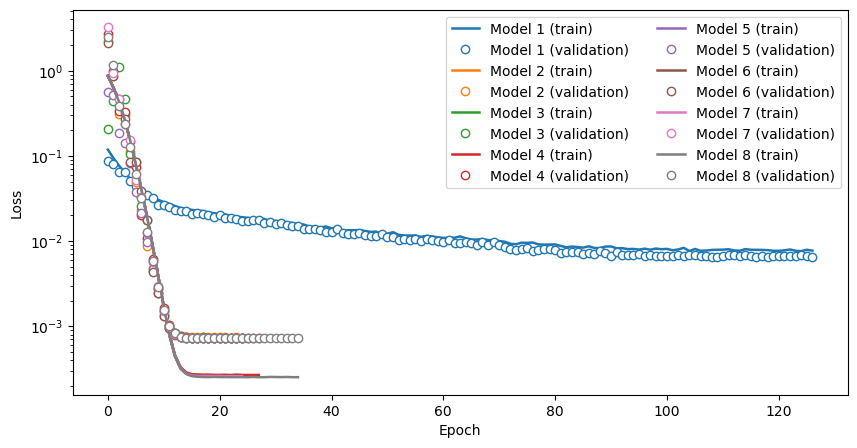

In [39]:

# 绘制损失曲线
plt.figure(figsize=(10, 5))
# boosting unet
for i in range(boosting_model.num_models):
    color = plt.cm.tab10(i)  # 或者 plt.cm.Set1(i) 等，获取第 i 种默认颜色

    # 训练：实线
    plt.plot(train_losses[i], 
             color=color,
             label=f'Model {i+1} (train)',
             linewidth=1.8)

    # 验证：同色点
    plt.plot(val_losses[i], 
             color=color,
             marker='o',
             linestyle='',
             markersize=6,
             markeredgewidth=1,
             markerfacecolor='white',   # 白色填充，更醒目
             markeredgecolor=color,
             label=f'Model {i+1} (validation)')
# tree unet
'''plt.plot(train_losses, label='Train Loss Model')
plt.plot(val_losses, label='Val Loss Model')'''
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend(ncol=2)
# plt.title('Training Loss Curve')
plt.show()
# 保存图片
# plt.savefig('../figs/training_loss_curve.png')

## 保存模型

In [21]:
# 保存模型，文件名后附加版本号
# torch.save(model.state_dict(), f'../datas/unet_{env_type}_model_v4.1.0.pth')
# 保存整个ensemble

# boosting unet
'''torch.save(boosting_model.state_dict(), f'../datas/boosting_unet_{env_type}_model_v5.7.pth')'''

# tree unet
'''torch.save(boosting_model.tree_model.state_dict(), f'../datas/tree_unet_{env_type}_model_v5.7.pth')'''

# boosting unet
torch.save(boosting_model.state_dict(), f'../datas/optim_xgboosting_unet_{env_type}_model_v6.3.pth')

## 读取模型

In [22]:
# 加载模型权重
# boosting unet
'''boosting_model.load_state_dict(torch.load(f'../datas/tree_unet_{env_type}_model_v5.7.pth', map_location=device))'''

# tree unet
'''state_dict = torch.load(f'../datas/tree_unet_{env_type}_model_v5.7.pth', map_location=device)
boosting_model.tree_model.load_state_dict(state_dict)'''

# xgboost unet
boosting_model.load_state_dict(torch.load(f'../datas/optim_xgboosting_unet_{env_type}_model_v6.3.pth', map_location=device))

<All keys matched successfully>

# 模型检验

## 选取样本并预测

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 步骤1: 从原始数据取一个样本（假设 wind_combined 和 output_map_2d 已加载且清理）
sample_idx = 4770 # 84710 Damrey # 97480 Haiyan # 100120 Sarika # 97950 rammasun # 取第sample_idx个样本；可改成其他索引
print("TC id: %d" % id[sample_idx])
print(f"Same Index: {sample_idx - np.where(id==id[sample_idx])[0][0]}")
wind_sample_real = wind_combined_clean[sample_idx, 0]  # (64, 64) real part
wind_sample_imag = wind_combined_clean[sample_idx, 1]  # (64, 64) imag part

# 步骤2: 标准化输入（匹配训练）
# 展平、transform、恢复形状
'''wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).transpose(1,2,0).reshape(-1, 2)
wind_sample_normalized = scaler_wind.transform(wind_sample_flat).reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)  # (1, 2, 64, 64)'''
wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).reshape(1, -1)  # (1, 2*64*64)
wind_sample_normalized_flat = scaler_wind.transform(wind_sample_flat)  # (1, 2*64*64)
wind_sample_normalized = wind_sample_normalized_flat.reshape(1, 2, 64, 64)  # (1, 2, 64, 64)

wind_sample_tensor = torch.from_numpy(wind_sample_normalized).float().to(device)

# 步骤3: 模型推理
boosting_model.eval()   # boosting unet
with torch.no_grad():
    env_pred_normalized = boosting_model(wind_sample_tensor)  # (1, 1, 64, 64)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (64, 64)

print(env_pred_normalized_np.shape)
print(f"maximum/minimum value of predict output: %.4f / %.4f" %(np.max(env_pred_normalized_np), np.min(env_pred_normalized_np)))

# 步骤4: 反归一化输出（恢复原始尺度）
if env_type == 'current':
    # 对于 current，有两个通道
    env_pred_flat = env_pred_normalized_np.transpose(1, 2, 0).reshape(-1, 2)  # (1, 2*64*64)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(1, 64, 64, 2).transpose(0, 3, 1, 2)  # (2, 64, 64)
else:
    '''env_pred_flat = env_pred_normalized_np.reshape(-1, 1)  # (1, 64*64)
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)'''
    env_pred_flat = env_pred_normalized_np.reshape(1, -1)  
    env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(64, 64)  # (64, 64)
# - wind_sample_real: (64, 64) 输入风场 real 部分
# - env_pred_np: (64, 64) 预测波浪场（反归一化后）
# - true_sample: (64, 64) 真实波浪场（从 output_map_2d[sample_idx]）
# - X, Y: meshgrid (64, 64)，Y 是 lat (行),  X 是 lon (列)
# 如果没有 true_sample，从数据集中取
true_sample = output_map_2d_clean[sample_idx]  # (64, 64)



TC id: 200020
Same Index: 20
(64, 64)
maximum/minimum value of predict output: 0.9584 / -0.0137


## 最值检验 -- 测试

In [24]:
# 输出测试和预报的最大值

if env_type == 'current':
    print("True U max value:", np.max(true_sample[0, :, :]))
    print("Predicted U max value:", np.max(env_pred_np[0, :, :]))
    print("True V max value:", np.max(true_sample[1, :, :]))
    print("Predicted V max value:", np.max(env_pred_np[1, :, :]))
else:
    print("True max value: %.4f" % np.max(true_sample))
    print("Predicted max value: %.4f" % np.max(env_pred_np))

True max value: 12.0712
Predicted max value: 11.6997


## 风场和变量场比较

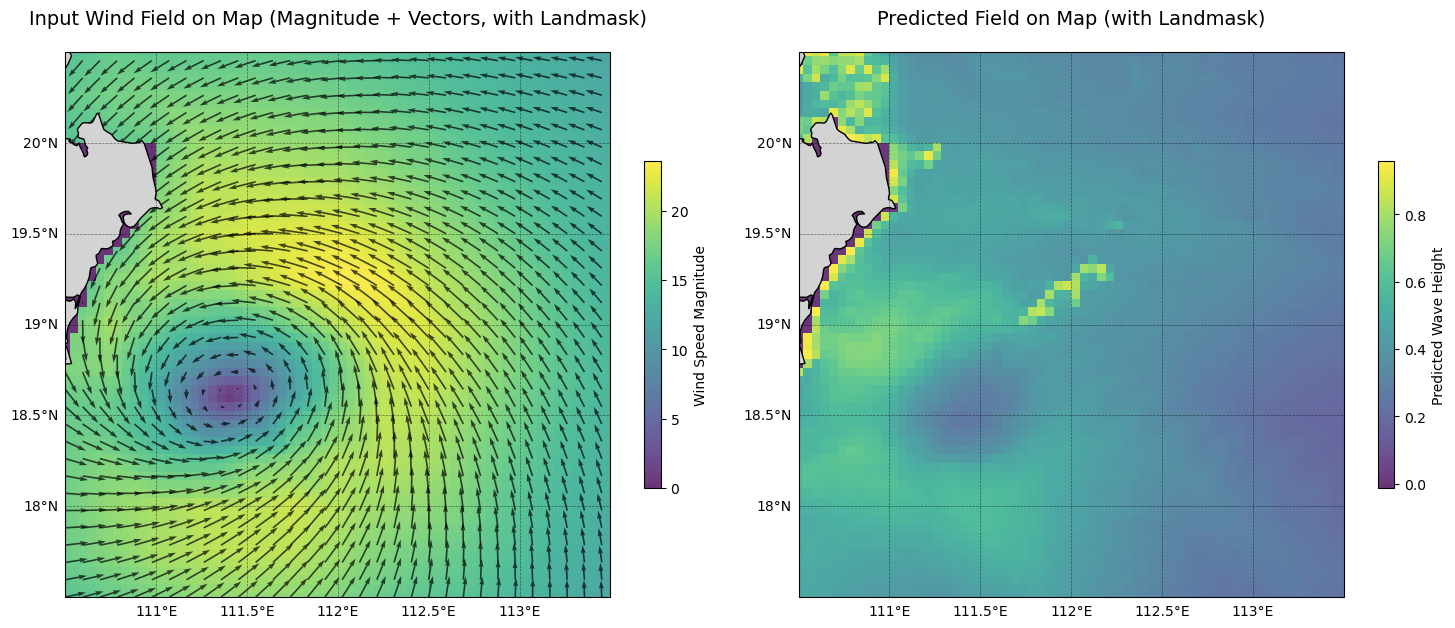

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_field_np = np.sqrt(wind_sample_real**2 + wind_sample_imag**2)

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
# 将quiver的箭头长度均设置成1
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_sample_real[::skip, ::skip]
Vq = wind_sample_imag[::skip, ::skip]
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
# Normalize vectors to length 1
'''magnitude = np.sqrt(Uq**2 + Vq**2)
Uq_norm = Uq / magnitude
Vq_norm = Vq / magnitude
ax1.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''

# Add land and features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field on Map (Magnitude + Vectors, with Landmask)', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
if env_type == 'current':
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im2 = ax2.pcolormesh(X, Y, env_pred_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im2, ax=ax2, label='Predicted Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0][::skip, ::skip]
    Vq = env_pred_np[1][::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax2.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im2 = ax2.pcolormesh(X, Y, env_pred_normalized_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        plt.colorbar(im2, ax=ax2, label='Predicted Wave Height', shrink=0.6)
    else:
        plt.colorbar(im2, ax=ax2, label='Predicted Surge Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title('Predicted Field on Map (with Landmask)', fontsize=14, pad=20)

plt.tight_layout()
# plt.show()
# Save figure
plt.savefig('../figs/sample_prediction_map.png', dpi=300)

## 实际场和预测场比较

MSE: 0.0602, MAE: 0.1626
Correlation: 0.9938
高值区 MAE: 0.2751


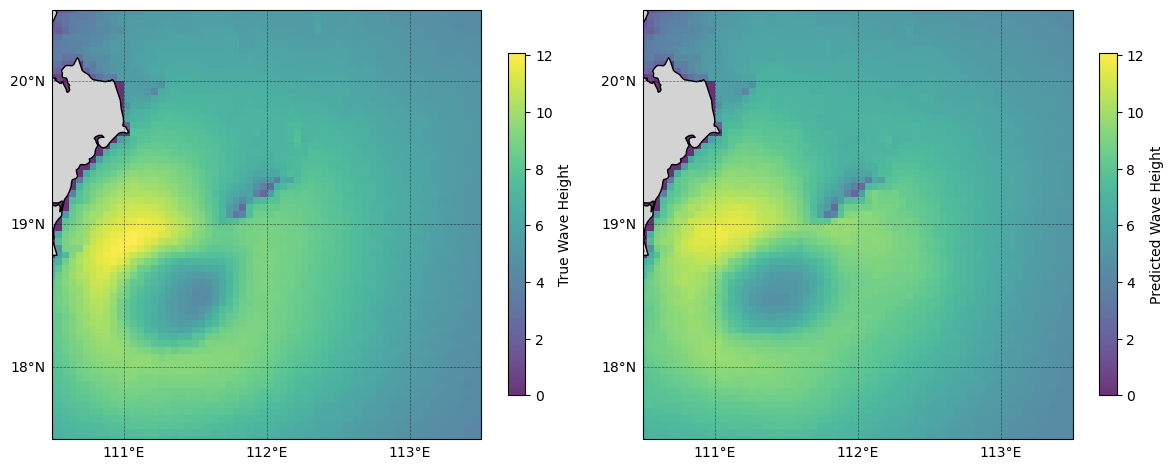

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 假设 X, Y, true_sample, env_pred_np 已定义；如果未定义，请加载数据

# 定义格式器（如果之前代码中已定义，可忽略）
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# 对比图：预测 vs 真实（子图）
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 6))
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]
# 真实场
ax1.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
if env_type == 'current':
    true_sample_abs = np.sqrt(true_sample[0]**2 + true_sample[1]**2)  # 计算流速幅值
    im_true = ax1.pcolormesh(X, Y, true_sample_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Current Speed', shrink=0.6)
    # ax1.set_title('True Current Field', fontsize=14, pad=20)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = true_sample[0][::skip, ::skip]
    Vq = true_sample[1][::skip, ::skip]
    ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax1.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_true = ax1.pcolormesh(X, Y, true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Wave Height', shrink=0.6)
        # ax1.set_title('True Wave Field', fontsize=14, pad=20)
    else:
        plt.colorbar(im_true, ax=ax1, orientation='vertical', label='True Surge Height', shrink=0.6)
        # ax1.set_title('True Surge Field', fontsize=14, pad=20)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

# 预测场
ax2.set_extent(extent, crs=ccrs.PlateCarree())
# pcolormesh for wave height
if env_type == 'current':
    env_pred_np_abs = np.sqrt(env_pred_np[0]**2 + env_pred_np[1]**2)  # 计算流速幅值
    im_pred = ax2.pcolormesh(X, Y, env_pred_np_abs, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    # ax2.set_title('Predicted Current Field', fontsize=14, pad=20)
    fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Current Speed', shrink=0.6)

    # Quiver for current vectors (subsample to avoid overcrowding)
    Uq = env_pred_np[0][::skip, ::skip]
    Vq = env_pred_np[1][::skip, ::skip]
    ax2.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=10, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed
    # Normalize vectors to length 1
    '''magnitude = np.sqrt(Uq**2 + Vq**2)
    Uq_norm = Uq / magnitude
    Vq_norm = Vq / magnitude
    ax2.quiver(Xq, Yq, Uq_norm, Vq_norm, transform=ccrs.PlateCarree(), scale=30, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed'''
else:
    im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
    if env_type == 'wave':
        # ax2.set_title('Predicted Wave Field', fontsize=14, pad=20)
        fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Predicted Wave Height', shrink=0.6)
    else:
        # ax2.set_title('Predicted Surge Field', fontsize=14, pad=20)
        fig.colorbar(im_pred, ax=ax2, orientation='vertical', label='Surge Height', shrink=0.6)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 添加colorbar并设置范围，与真实场一致（在 im_pred 上调用 set_clim）
im_pred.set_clim(vmin=im_true.get_clim()[0], vmax=im_true.get_clim()[1])  # 修复：移到 im_pred 上
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl2.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

plt.tight_layout()
# plt.show()
# 保存图片
plt.savefig('../figs/sample_prediction_comparison.png', dpi=300)

# 打印对比统计
mse = np.mean((env_pred_np - true_sample)**2)
mae = np.mean(np.abs(env_pred_np - true_sample))
correlation = np.corrcoef(env_pred_np.flatten(), true_sample.flatten())[0, 1]
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {correlation:.4f}")

# 高值区域 MAE
high_region = true_sample > np.percentile(true_sample, 90)
print(f"高值区 MAE: {np.mean(np.abs(env_pred_np[high_region] - true_sample[high_region])):.4f}")

##### 查询指定位置的值

At position (110.6, 18.7), True value: 9.1179, Predicted value: 9.0372


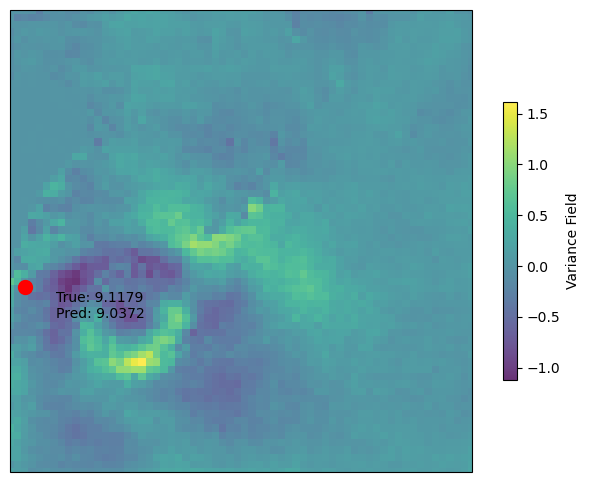

In [27]:
# 给定坐标位置经纬度
position = (110.6, 18.7)
# 查找最近的网格点索引
lon_idx = (np.abs(X[0, :] - position[0])).argmin()
lat_idx = (np.abs(Y[:, 0] - position[1])).argmin()

true_value = true_sample[lat_idx, lon_idx]
pred_value = env_pred_np[lat_idx, lon_idx]
print(f"At position {position}, True value: {true_value:.4f}, Predicted value: {pred_value:.4f}")

# 在图上标注该位置
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
extent = [np.min(x), np.max(x), np.min(y), np.max(y)]
ax.set_extent(extent, crs=ccrs.PlateCarree())
im = ax.pcolormesh(X, Y, env_pred_np-true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im, ax=ax, label='Variance Field', shrink=0.6)
# ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
ax.plot(position[0], position[1], marker='o', color='red', markersize=10, transform=ccrs.PlateCarree())
ax.text(position[0]+0.2, position[1]-0.2, f"True: {true_value:.4f}\nPred: {pred_value:.4f}", transform=ccrs.PlateCarree())

# plt.show()
# 保存图片
plt.savefig('../figs/sample_prediction_location.png', dpi=300)

# 清理全部内存

In [28]:
import IPython

# restart=True 表示重启，False 表示仅关闭
# app = IPython.Application.instance()
# app.kernel.do_shutdown(restart=True)